<a href="https://colab.research.google.com/github/haribojjireddy/my-first-repo/blob/main/B2_SQL_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip3 install db-sqlite3

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for db-sqlite3: filename=db_sqlite3-0.0.1-py3-none-any.whl size=1768 sha256=8012b01cddbe9f5c3766feb144a6b9a32858581e8a549e73a9f85d20c214466e
  Stored in directory: /root/.cache/pip/wheels/fe/5a/c7/5bc48efba8859978617693442869e925d6f51447c0c9521a53
  Created wheel for db: filename=db-0.1.1-py3-none-any.whl size=3873 sha256=49eacacc0e552ef149f8da8ddced77ddb9fce7cacc017bc938b40e79bf1fd39d
  Stored in directory: /root/.cache/pip/wheels/b3/be/81/a4ce37a0114cd102481c28ff6951d63be24e0c3750af04e4e7
  Created wheel for antiorm: filename=antiorm-1.2.1-py3-none-any.whl size=31666 sha256=4e330b062a3f7ada68d4210ad471cb6e3d251dd584ae971884bdb3141828b3c0
  Stored in directory: /root/.cache/pip/wheels/59/f2/19/6d79c922072d86a15f1e89bea01335e989cf0a60038d6b3b1e
Successfully built db-sql

In [ ]:
import sqlite3

In [ ]:
print(sqlite3.version)
print(sqlite3.sqlite_version)

2.6.0
3.37.2


/tmp/ipykernel_41283/1853462571.py:1: DeprecationWarning: version is deprecated and will be removed in Python 3.14
  print(sqlite3.version)


In [ ]:
conn = sqlite3.connect("my_database.db")

In [ ]:
conn = sqlite3.connect("my_database.db")
cursor = conn.cursor()

cursor.execute('''CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT NOT NULL,
    category TEXT,
    price REAL NOT NULL,
    stock INTEGER DEFAULT 0,
    created_date DATE
);''')

conn.commit()
conn.close()

In [ ]:
import sqlite3

# Automatically handles closing
with sqlite3.connect('my_database.db') as conn:
    cursor = conn.cursor()
    cursor.execute('''CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT NOT NULL,
    category TEXT,
    price REAL NOT NULL,
    stock INTEGER DEFAULT 0,
    created_date DATE
);''')
    conn.commit()


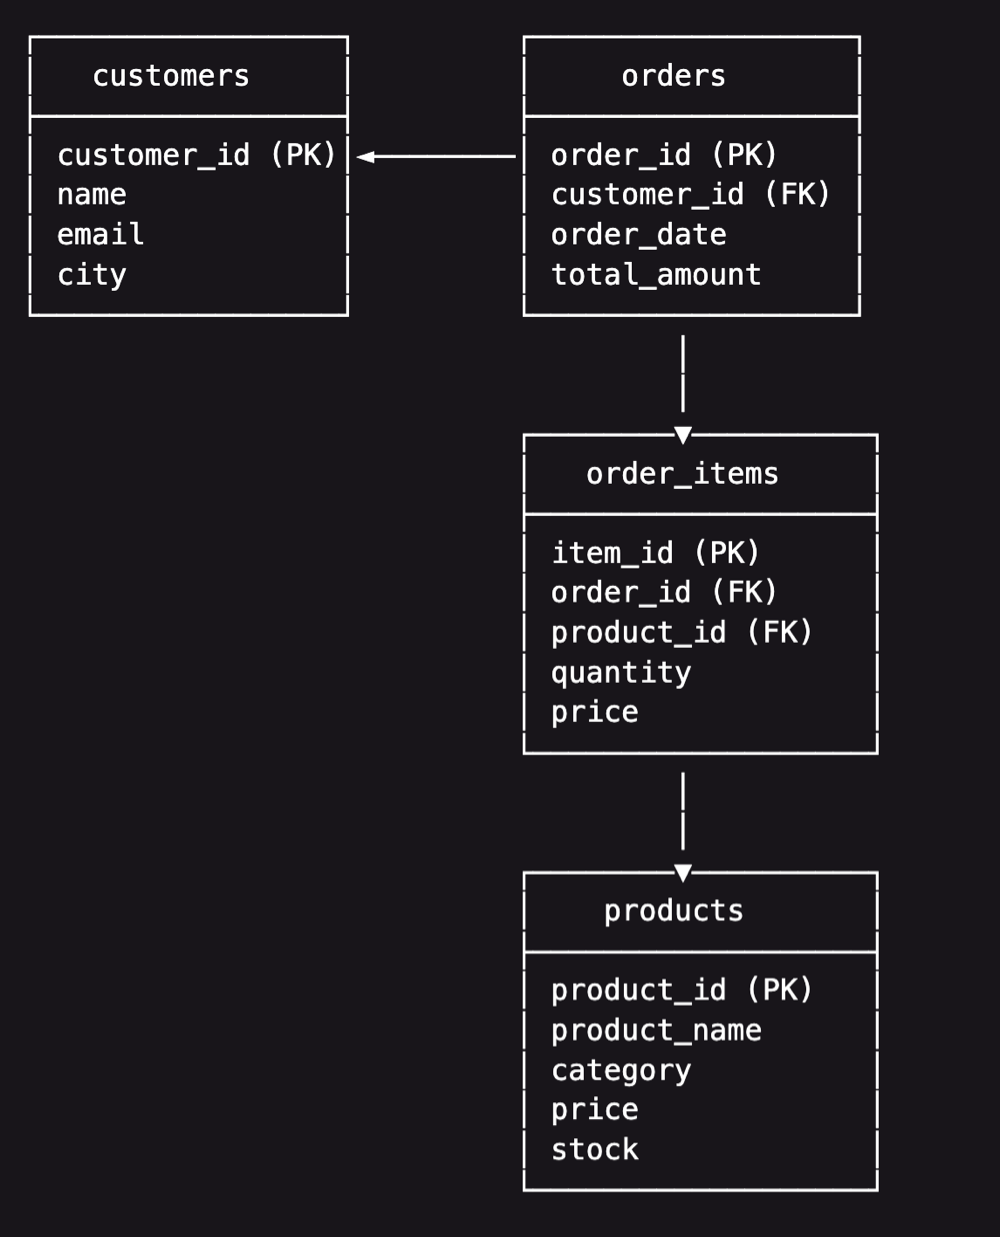

In [ ]:
import sqlite3

# Connect to database (creates file if it doesn't exist)
conn = sqlite3.connect('ecommerce.db')
cursor = conn.cursor()

# Table 1: Customers
cursor.execute('''
CREATE TABLE IF NOT EXISTS customers (
    customer_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    email TEXT NOT NULL,
    city TEXT,
    signup_date DATE
)
''')


# Table 2: Products
cursor.execute('''
CREATE TABLE IF NOT EXISTS products (
    product_id INTEGER PRIMARY KEY AUTOINCREMENT,
    product_name TEXT NOT NULL,
    category TEXT,
    price REAL NOT NULL,
    stock INTEGER DEFAULT 0
)
''')


# Table 3: Orders
cursor.execute('''
CREATE TABLE IF NOT EXISTS orders (
    order_id INTEGER PRIMARY KEY AUTOINCREMENT,
    customer_id INTEGER NOT NULL,
    order_date DATE NOT NULL,
    total_amount REAL NOT NULL,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
)
''')

# Table 4: Order Items (junction table)
cursor.execute('''
CREATE TABLE IF NOT EXISTS order_items (
    item_id INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    quantity INTEGER NOT NULL,
    price REAL NOT NULL,
    FOREIGN KEY (order_id) REFERENCES orders(order_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
)
''')

# Table 5: Reviews
cursor.execute('''
CREATE TABLE IF NOT EXISTS reviews (
    review_id INTEGER PRIMARY KEY AUTOINCREMENT,
    product_id INTEGER NOT NULL,
    customer_id INTEGER NOT NULL,
    rating INTEGER CHECK(rating >= 1 AND rating <= 5),
    review_text TEXT,
    review_date DATE,
    FOREIGN KEY (product_id) REFERENCES products(product_id),
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id)
)
''')


conn.commit()
print("All tables created successfully!")
conn.close()


All tables created successfully!


In [ ]:
import pandas as pd
# Create the DataFrame
data = {
    'date': ['20.05.26', '21.05.26', '22.05.26', '23.05.26', '24.05.26', '25.05.26'],
    'category': ['Electronics', 'Groceries', 'Clothing', 'Groceries', 'Clothing', 'Electronics'],
    'units_sold': [60, 50, 10, 65, 150, 55],
    'revenue': [70, 55, 15, 68, 200, 52],
    'discount_pct': [10, 5, 2, 8, 16, 20]
}

df = pd.DataFrame(data)
df

,date,category,units_sold,revenue,discount_pct
0,20.05.26,Electronics,60,70,10
1,21.05.26,Groceries,50,55,5
2,22.05.26,Clothing,10,15,2
3,23.05.26,Groceries,65,68,8
4,24.05.26,Clothing,150,200,16
5,25.05.26,Electronics,55,52,20


In [ ]:
import matplotlib.pyplot as plt

<Axes: title={'center': 'revenue'}, xlabel='category'>

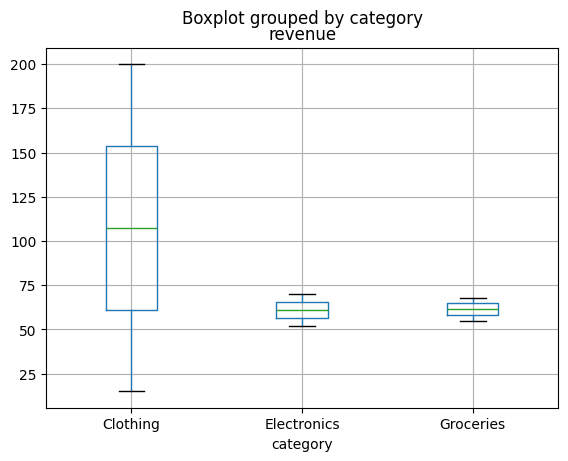

In [ ]:
df.boxplot(column = 'revenue', by = 'category')

{'whiskers': [<matplotlib.lines.Line2D at 0x7e48f1ae4d40>,
 'caps': [<matplotlib.lines.Line2D at 0x7e48f1ae5340>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e490278fc80>],
 'medians': [<matplotlib.lines.Line2D at 0x7e48f1ae58e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e48f1ae5be0>],
 'means': []}

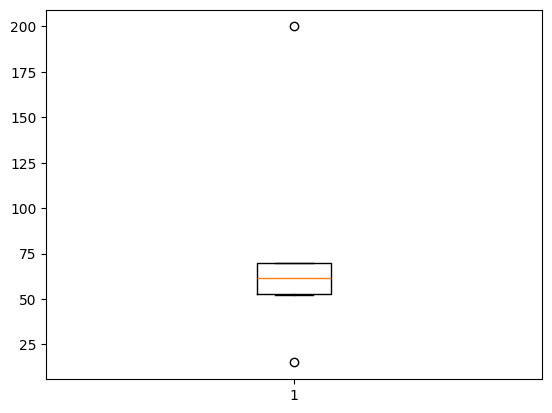

In [ ]:
plt.boxplot(df['revenue'])

<Axes: xlabel='revenue'>

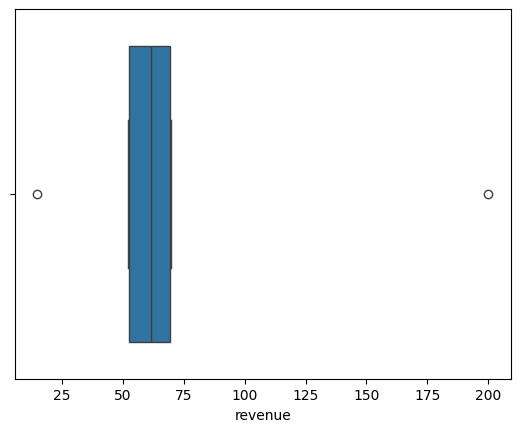

In [ ]:
import seaborn as sns
sns.boxplot(df, x='revenue')

In [ ]:
import seaborn as sns
sns.boxplot(df, x='revenue', by='category')